# EDA,Cleaning, and Analysis

In [1]:
import pandas as pd

# read file
df = pd.read_csv("soccer_match_data.csv")

In [2]:
#load data
print("=== FIRST 5 ROWS ===")
print(df.head())

=== FIRST 5 ROWS ===
   match_id difficulty_level  shots  goals  saves  power_shot_count
0         1           Normal     10      2      8                 2
1         2           Normal     10      4      6                 5
2         3           Normal     10      5      5                 5
3         4             Easy     10      8      2                 1
4         5             Easy     10      8      2                 0


In [3]:
print("\n=== MISSING VALUES ===")
print(df.isnull().sum())
# no missing value in our data


=== MISSING VALUES ===
match_id            0
difficulty_level    0
shots               0
goals               0
saves               0
power_shot_count    0
dtype: int64


In [4]:
df = df.drop_duplicates() # drop duplicates

In [5]:
print("\n=== DUPLICATES ===")
print("Duplicate rows:", df.duplicated().sum())
# no duplicates


=== DUPLICATES ===
Duplicate rows: 0


In [6]:
# Check invalid values
invalid_rows = df[df["goals"] > df["shots"]]
print("\n=== INVALID ROWS (goals > shots) ===")
print(invalid_rows)


=== INVALID ROWS (goals > shots) ===
Empty DataFrame
Columns: [match_id, difficulty_level, shots, goals, saves, power_shot_count]
Index: []


In [7]:
# Remove invalid rows
df = df[df["goals"] <= df["shots"]]

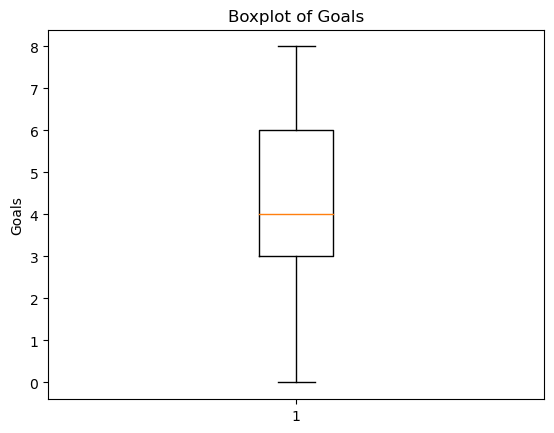

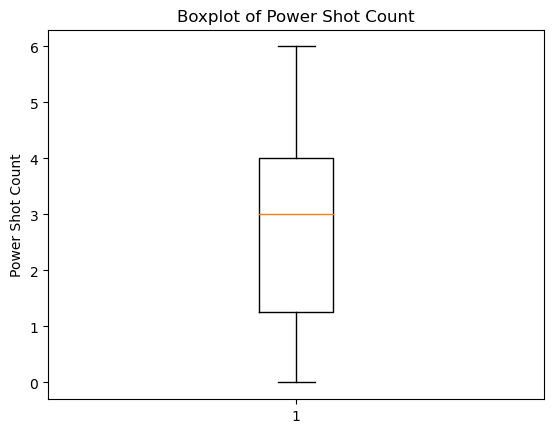

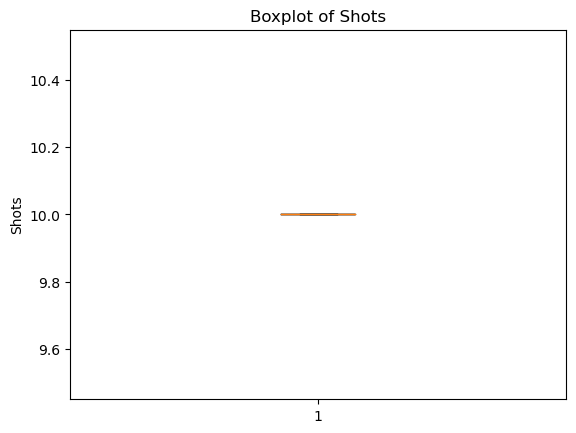

In [9]:
import matplotlib.pyplot as plt

# ==============================
# BOXPLOTS FOR OUTLIERS
# ==============================

# Boxplot for Goals
plt.figure()
plt.boxplot(df["goals"])
plt.title("Boxplot of Goals")
plt.ylabel("Goals")
plt.show()


# Boxplot for Power Shot Count
plt.figure()
plt.boxplot(df["power_shot_count"])
plt.title("Boxplot of Power Shot Count")
plt.ylabel("Power Shot Count")
plt.show()


# Boxplot for Shots (optional but good)
plt.figure()
plt.boxplot(df["shots"])
plt.title("Boxplot of Shots")
plt.ylabel("Shots")
plt.show()
# Note that we are expecting the user to shot 10 times 

# we have not outliers to remove in data

In [12]:
# feature engineering
df["accuracy"] = df["goals"] / df["shots"]

In [13]:
df.describe()

,match_id,shots,goals,saves,power_shot_count,accuracy
count,150.000000,150.0,150.000000,150.000000,150.000000,150.000000
mean,75.500000,10.0,4.246667,5.753333,2.700000,0.424667
std,43.445368,0.0,2.258278,2.258278,1.616816,0.225828
min,1.000000,10.0,0.000000,2.000000,0.000000,0.000000
25%,38.250000,10.0,3.000000,4.000000,1.250000,0.300000
50%,75.500000,10.0,4.000000,6.000000,3.000000,0.400000
75%,112.750000,10.0,6.000000,7.000000,4.000000,0.600000
max,150.000000,10.0,8.000000,10.000000,6.000000,0.800000


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 150 entries, 0 to 149
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   match_id          150 non-null    int64  
 1   difficulty_level  150 non-null    object 
 2   shots             150 non-null    int64  
 3   goals             150 non-null    int64  
 4   saves             150 non-null    int64  
 5   power_shot_count  150 non-null    int64  
 6   accuracy          150 non-null    float64
dtypes: float64(1), int64(5), object(1)
memory usage: 9.4+ KB


In [16]:
df.head(6)

,match_id,difficulty_level,shots,goals,saves,power_shot_count,accuracy
0,1,Normal,10,2,8,2,0.2
1,2,Normal,10,4,6,5,0.4
2,3,Normal,10,5,5,5,0.5
3,4,Easy,10,8,2,1,0.8
4,5,Easy,10,8,2,0,0.8
5,6,Normal,10,5,5,1,0.5


In [15]:
df.to_csv("cleaned_soccer_data.csv", index=False)
#cleaned dataset

In [1]:
# Hypothesis Testing: Impact of Difficulty Level on Goals Scored
import pandas as pd
from scipy.stats import ttest_ind

# Load dataset
df = pd.read_csv("cleaned_soccer_data.csv")

# Check available difficulty levels
print("Difficulty levels:\n", df["difficulty_level"].value_counts())

# Select groups (adjust if no "Hard" exists)
easy_goals = df[df["difficulty_level"] == "Easy"]["goals"]
normal_goals = df[df["difficulty_level"] == "Normal"]["goals"]

# Perform t-test
t_stat, p_value = ttest_ind(easy_goals, normal_goals, equal_var=False)

# Output results
print("\n--- T-Test Results ---")
print("Easy mean:", easy_goals.mean())
print("Normal mean:", normal_goals.mean())
print("T-statistic:", t_stat)
print("P-value:", p_value)

# Interpretation
if p_value < 0.05:
    print("\nResult: Significant difference between Easy and Normal difficulty.")
else:
    print("\nResult: No significant difference between Easy and Normal difficulty.")


Difficulty levels:
 Easy      57
Normal    54
Hard      39
Name: difficulty_level, dtype: int64

--- T-Test Results ---
Easy mean: 6.280701754385965
Normal mean: 3.8333333333333335
T-statistic: 9.223962714154633
P-value: 2.5420641763024257e-15

Result: Significant difference between Easy and Normal difficulty.


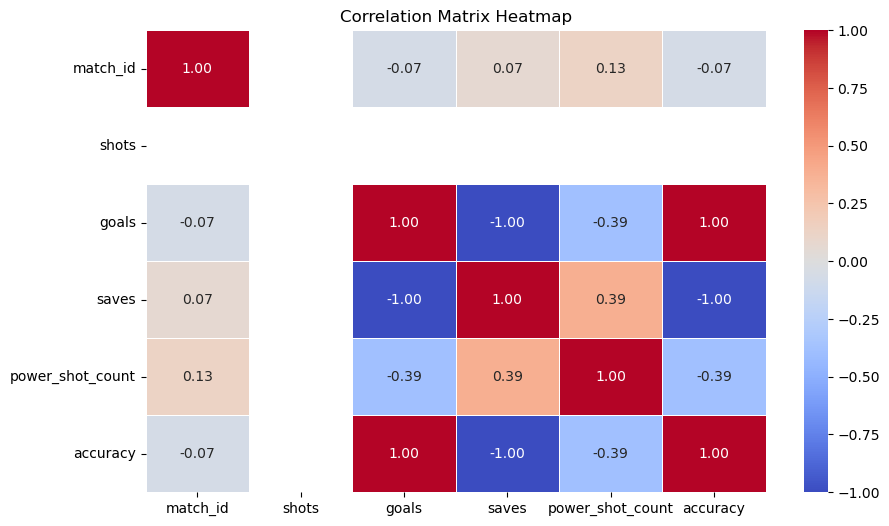

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv("cleaned_soccer_data.csv")
plt.figure(figsize=(10, 6))

# Compute correlation matrix (only numeric columns)
corr_matrix = df.corr(numeric_only=True)

# Plot heatmap
sns.heatmap(corr_matrix, 
            annot=True,       # show values
            cmap="coolwarm",  # color style
            fmt=".2f",        # 2 decimal places
            linewidths=0.5)

plt.title("Correlation Matrix Heatmap")
plt.show()

### Correlation Analysis Interpretation:

The heatmap shows that goals are strongly positively correlated with accuracy (1.00), meaning higher accuracy leads to more goals. Goals are strongly negatively correlated with saves (-1.00), indicating that more saves reduce scoring.
Power shot count has a moderate negative relationship with goals (-0.39), suggesting it may be less effective.
Some perfect correlations (±1.00) suggest the data is simulated or contains derived features.
Overall, accuracy appears to be the most important factor influencing goals.

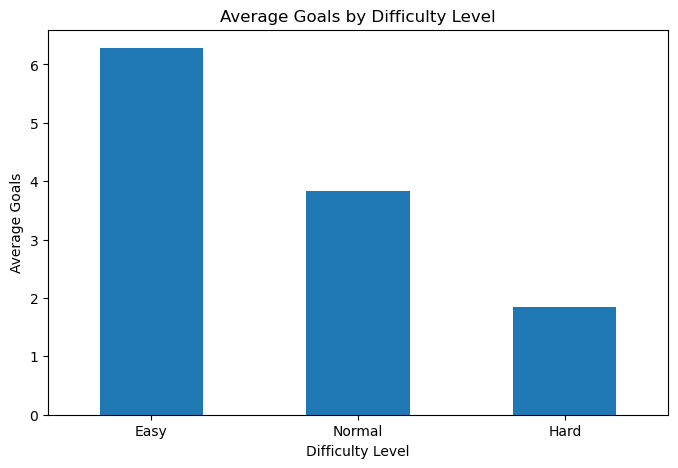

In [8]:
# Bivariate Analysis (sorted by logical difficulty order)
order = ["Easy", "Normal", "Hard"]

grouped = df.groupby("difficulty_level")["goals"].mean().reindex(order)

# Plot
grouped.plot(kind="bar", figsize=(8,5))
plt.title("Average Goals by Difficulty Level")
plt.xlabel("Difficulty Level")
plt.ylabel("Average Goals")
plt.xticks(rotation=0)
plt.show()

The bar chart shows that average goals decrease as difficulty increases. Easy mode has the highest average goals, followed by Normal, while Hard mode has the lowest.This indicates a clear negative relationship between difficulty level and scoring performance, where higher difficulty reduces the likelihood of scoring goals.